<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO
El dataset fue diseñado por el Canadian Institute for Cybersecurity (CIC) para el desarrollo y evaluación de sistemas de detección de intrusiones. Contiene más de 2,8 millones de instancias capturadas durante 5 días, incluyendo tráfico normal y ataques como Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack e Infiltración. Tiene 79 columnas con 78 features numéricas y una columna categórica de etiqueta (Label).

Fuente: https://www.unb.ca/cic/datasets/ids-2017.html

https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset

### Definición del Problema

El problema consiste en desarrollar un Sistema de Detección de Intrusiones (IDS) basado en aprendizaje supervisado que sea capaz de clasificar flujos de tráfico de red en tiempo real. El sistema debe distinguir entre tráfico benigno y actividades maliciosas (ataques) con alta precisión, permitiendo una respuesta rápida ante incidentes de seguridad.

In [9]:
# Librerias
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# Carga del dataset

# Configuración de carpetas
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Dataset"

# Buscar todos los archivos .parquet en esa carpeta automáticamente
parquet_files = glob.glob(os.path.join(DATA_DIR, "*.parquet"))

# Unir todos los archivos en uno solo
dfs_list = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    dfs_list.append(df_temp)

df = pd.concat(dfs_list, ignore_index=True)

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip()

print(f"Dataset cargado con {df.shape[0]} filas y con {df.shape[1]} columnas.")

Dataset cargado con 2830743 filas y con 79 columnas.


# EDA — ANÁLISIS EXPLORATORIO

### 1. Inspección Visual y Estructura

In [ ]:
# Ver las primeras 5 filas
pd.set_option('display.max_rows', None)
df.head().T.round(2)

,0,1,2,3,4
Destination Port,54865,55054,55055,46236,54863
Flow Duration,3,109,52,34,3
Total Fwd Packets,2,1,1,1,2
Total Backward Packets,0,1,1,1,0
Total Length of Fwd Packets,12,6,6,6,12
Total Length of Bwd Packets,0,6,6,6,0
Fwd Packet Length Max,6,6,6,6,6
Fwd Packet Length Min,6,6,6,6,6
Fwd Packet Length Mean,6.0,6.0,6.0,6.0,6.0
Fwd Packet Length Std,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Información general: tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [ ]:
# Verificar si hay valores nulos (NaN)
print("Valores nulos por columna:")
df.isnull().sum()

Valores nulos por columna:


,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0


### 2. Estadísticas Descriptivas

In [ ]:
# Resumen estadístico de las columnas numéricas
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.00,8071.48,18283.63,0.00,53.00,80.00,443.00,65535.00
Flow Duration,2830743.00,14785663.93,33653744.09,-13.00,155.00,31316.00,3204828.50,119999998.00
Total Fwd Packets,2830743.00,9.36,749.67,1.00,2.00,2.00,5.00,219759.00
Total Backward Packets,2830743.00,10.39,997.39,0.00,1.00,2.00,4.00,291922.00
Total Length of Fwd Packets,2830743.00,549.30,9993.59,0.00,12.00,62.00,187.00,12900000.00
Total Length of Bwd Packets,2830743.00,16162.64,2263088.05,0.00,0.00,123.00,482.00,655453030.00
Fwd Packet Length Max,2830743.00,207.60,717.18,0.00,6.00,37.00,81.00,24820.00
Fwd Packet Length Min,2830743.00,18.71,60.34,0.00,0.00,2.00,36.00,2325.00
Fwd Packet Length Mean,2830743.00,58.20,186.09,0.00,6.00,34.00,50.00,5940.86
Fwd Packet Length Std,2830743.00,68.91,281.19,0.00,0.00,0.00,26.16,7125.60


### 3. Análisis de la Variable Objetivo (Label)

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


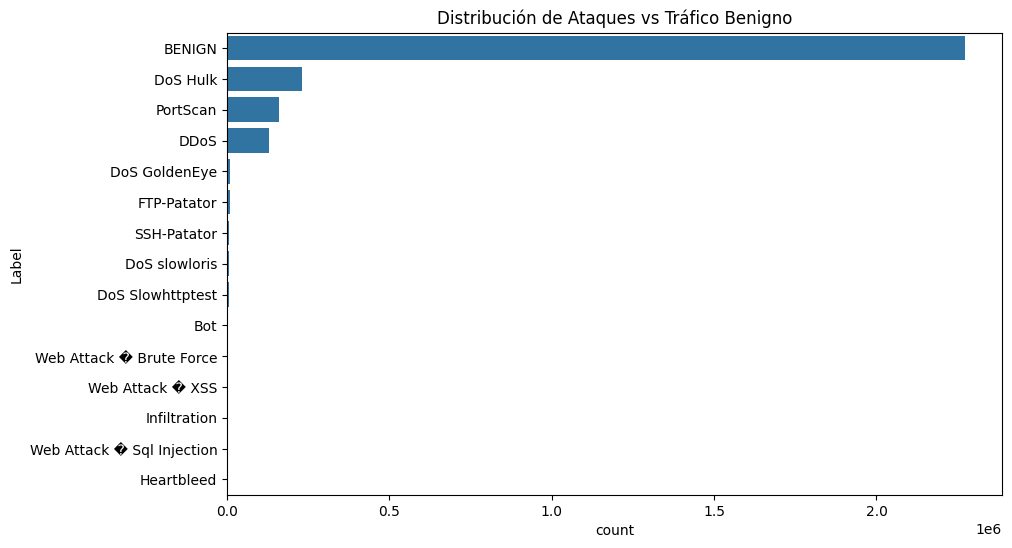

In [ ]:
# Contar cuántos registros hay de cada clase
print(df['Label'].value_counts())

# Graficar la distribución de las clases
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Label', order=df['Label'].value_counts().index)
plt.title('Distribución de Ataques vs Tráfico Benigno')
plt.show()

### 4. Análisis de Correlación

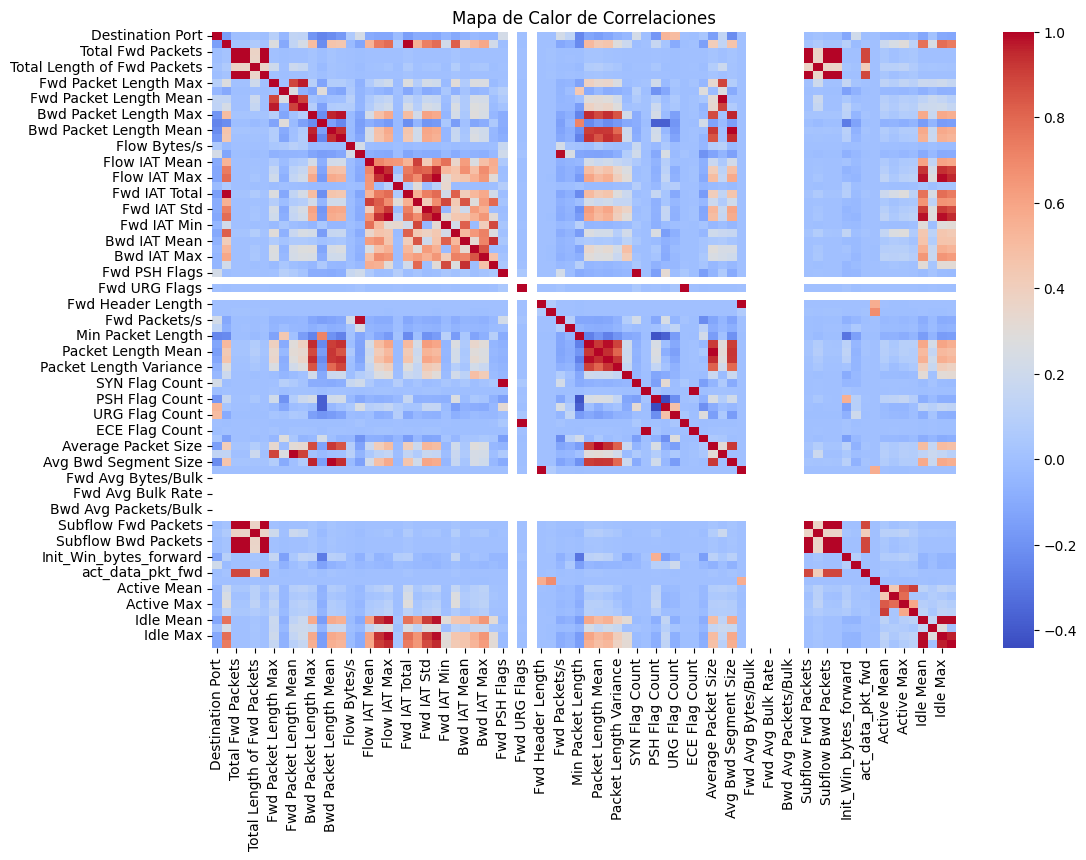

In [ ]:
# Seleccionar solo columnas numéricas para la correlación
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Mapa de Calor de Correlaciones')
plt.show()